In [1]:
import yfinance as yf
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt


In [2]:
tickers = ['AAPL', 'MSFT', 'AMZN', 'JNJ', 'XOM']

start_date = '2000-01-01'
end_date = '2025-01-01'

df = yf.download(tickers, start=start_date, end=end_date, group_by='ticker',) 


[*********************100%***********************]  5 of 5 completed


In [3]:
df.head()

Ticker          AMZN                                                MSFT  \
Price           Open      High       Low     Close     Volume       Open   
Date                                                                       
2000-01-03  4.075000  4.478125  3.952344  4.468750  322352000  36.114058   
2000-01-04  4.268750  4.575000  4.087500  4.096875  349748000  34.941031   
2000-01-05  3.525000  3.756250  3.400000  3.487500  769148000  34.191052   
2000-01-06  3.565625  3.634375  3.200000  3.278125  375040000  34.517954   
2000-01-07  3.350000  3.525000  3.309375  3.478125  210108000  33.421867   

Ticker                                                 ...        XOM  \
Price            High        Low      Close    Volume  ...       Open   
Date                                                   ...              
2000-01-03  36.498659  34.460272  35.864067  53228400  ...  18.160074   
2000-01-04  36.037145  34.537200  34.652580  54119000  ...  17.674674   
2000-01-05  35.806377  33.652610  35.017944  64059600  ...  17.817445   
2000-01-06  35.037166  33.344921  33.844902  54976600  ...  18.417063   
2000-01-07  34.537211  33.018035  34.287220  62013600  ...  19.630582   

Ticker                                                       JNJ             \
Price            High        Low      Close    Volume       Open       High   
Date                                                                          
2000-01-03  18.445610  17.788877  17.888815  13458200  24.367755  24.531297   
2000-01-04  17.860272  17.474799  17.546183  14510800  23.844434  23.958913   
2000-01-05  18.674053  17.774615  18.502731  17485000  23.239335  23.762669   
2000-01-06  19.602036  18.317125  19.459269  19461600  23.631835  24.580379   
2000-01-07  19.701966  19.188001  19.402153  16603800  24.629431  25.365370   

Ticker                                     
Price             Low      Close   Volume  
Date                                       
2000-01-03  23.958900  24.122442  4642400  
2000-01-04  23.222974  23.239328  7822200  
2000-01-05  23.141209  23.484648  8229600  
2000-01-06  23.582773  24.220587  5356400  
2000-01-07  24.498597  25.250891  9863800  

[5 rows x 25 columns]

In [4]:
df.columns

MultiIndex([('AMZN',   'Open'),
            ('AMZN',   'High'),
            ('AMZN',    'Low'),
            ('AMZN',  'Close'),
            ('AMZN', 'Volume'),
            ('MSFT',   'Open'),
            ('MSFT',   'High'),
            ('MSFT',    'Low'),
            ('MSFT',  'Close'),
            ('MSFT', 'Volume'),
            ('AAPL',   'Open'),
            ('AAPL',   'High'),
            ('AAPL',    'Low'),
            ('AAPL',  'Close'),
            ('AAPL', 'Volume'),
            ( 'XOM',   'Open'),
            ( 'XOM',   'High'),
            ( 'XOM',    'Low'),
            ( 'XOM',  'Close'),
            ( 'XOM', 'Volume'),
            ( 'JNJ',   'Open'),
            ( 'JNJ',   'High'),
            ( 'JNJ',    'Low'),
            ( 'JNJ',  'Close'),
            ( 'JNJ', 'Volume')],
           names=['Ticker', 'Price'])

In [5]:
all_dates = df.index.unique().sort_values()

In [6]:
len(all_dates)

6289

In [7]:
#Start dates are chose based on the first trading day of the week
start = all_dates.get_loc('2000-01-03')
end = all_dates.get_loc('2024-12-31')
dates = all_dates[start:end+1]



In [8]:
print(all_dates)
print(type(all_dates))

DatetimeIndex(['2000-01-03', '2000-01-04', '2000-01-05', '2000-01-06',
               '2000-01-07', '2000-01-10', '2000-01-11', '2000-01-12',
               '2000-01-13', '2000-01-14',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=6289, freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [9]:
type(dates)

pandas.core.indexes.datetimes.DatetimeIndex

In [10]:
len(dates)

6289

In [11]:
#Starting a dataframe that will only be based on closing prices
close_prices = pd.DataFrame(index=dates)

In [12]:
# names = df['Name'].unique()
names = ['AAPL', 'MSFT', 'AMZN', 'JNJ', 'XOM']

In [13]:
# Extract 'Close' prices
close_prices = df.loc[:, (slice(None), 'Close')]

# Rename the columns to simplify (e.g., just the tickers)
close_prices.columns = close_prices.columns.droplevel(1)

# Check the result
print(close_prices.head())

Ticker          AMZN       MSFT      AAPL        XOM        JNJ
Date                                                           
2000-01-03  4.468750  35.864067  0.843076  17.888815  24.122442
2000-01-04  4.096875  34.652580  0.771996  17.546183  23.239328
2000-01-05  3.487500  35.017944  0.783293  18.502731  23.484648
2000-01-06  3.278125  33.844902  0.715509  19.459269  24.220587
2000-01-07  3.478125  34.287220  0.749402  19.402153  25.250891


In [14]:
close_prices.isna().sum().sum()
#To check for any missing data-- would then use forward filling and backward filling to fill in the missing data
#close_prices.fillna(method='ffill', inplace=True)

np.int64(0)

In [15]:
# empty dataframe
returns = pd.DataFrame(index=dates[1:])

In [16]:
# Initialize a DataFrame for storing returns
returns = pd.DataFrame(index=close_prices.index)

# Calculate percentage returns for each ticker
for name in close_prices.columns:  # Iterate over tickers
    current_returns = close_prices[name].pct_change()  # Calculate daily returns
    returns[name] = current_returns.iloc[1:] * 100  # Store returns as percentages

# Check the result
print(returns.head())

                 AMZN      MSFT      AAPL       XOM       JNJ
Date                                                         
2000-01-03        NaN       NaN       NaN       NaN       NaN
2000-01-04  -8.321674 -3.377996 -8.431016 -1.915344 -3.660964
2000-01-05 -14.874147  1.054363  1.463332  5.451606  1.055622
2000-01-06  -6.003582 -3.349832 -8.653803  5.169708  3.133703
2000-01-07   6.101050  1.306897  4.736883 -0.293513  4.253836


In [17]:
mean_return = returns.mean()
#mean daily return over the period of time 2000-2025

In [18]:
mean_return

AMZN    0.109474
MSFT    0.057294
AAPL    0.121595
XOM     0.042264
JNJ     0.035752
dtype: float64

In [19]:
cov = returns.cov()

In [20]:
cov

,AMZN,MSFT,AAPL,XOM,JNJ
AMZN,9.666859,2.618327,2.815059,0.945032,0.565485
MSFT,2.618327,3.622071,2.233052,1.120540,0.748027
AAPL,2.815059,2.233052,5.954554,1.075077,0.660699
XOM,0.945032,1.120540,1.075077,2.749741,0.800351
JNJ,0.565485,0.748027,0.660699,0.800351,1.450215


In [21]:
#will be converting covariance matrix to a numpy array for the purpose of indexing 
cov_np = cov.to_numpy()

In [22]:
#Following code will generate a bunch of random portfolios
N = 10000
D = len(mean_return) # number of assets
returns = np.zeros(N) # where we will store returns and risks
risks = np.zeros(N)   # ^^

for i in range(N):
    rand_range = 1.0
    w = np.random.random(D)*rand_range - rand_range/2 #shorting allowed
    w[-1] = 1- w[:-1].sum() #to meet constraint of w summing to 1
    np.random.shuffle(w) #randomize the order of the weights
    ret = mean_return.dot(w)
    risk = np.sqrt(w.dot(cov_np).dot(w))
    returns[i] = ret
    risks[i] = risk

In [23]:
single_asset_returns = np.zeros(D)
single_asset_risks = np.zeros(D)
for i in range(D):
    ret = mean_return[i]
    risk = np.sqrt(cov_np[i,i]) #standard deviation

    single_asset_returns[i] = ret
    single_asset_risks[i] = risk


C:\Users\ognal\AppData\Local\Temp\ipykernel_39224\383768557.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret = mean_return[i]


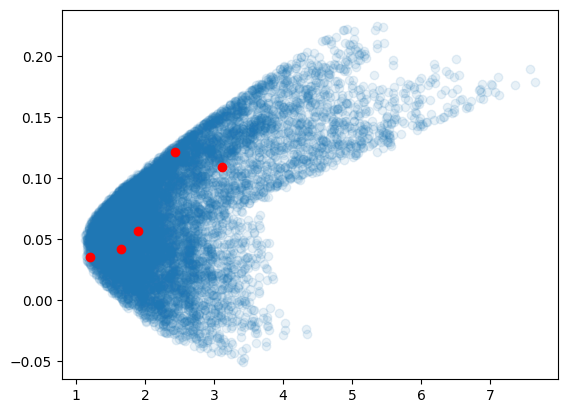

In [24]:
plt.scatter(risks, returns, alpha=0.1);
plt.scatter(single_asset_risks, single_asset_returns, color='red');

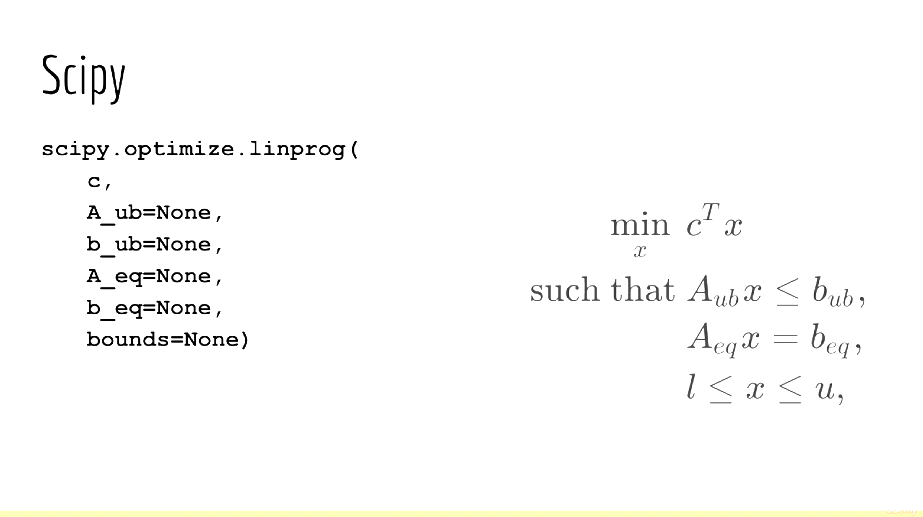

In [25]:
#lin prog minimizes ie if you want to maximize, pass negative c 
from scipy.optimize import linprog

In [26]:
D = len(mean_return)

In [27]:
A_eq = np.ones((1,D))
b_eq = np.ones(1)

In [28]:
### NOTE: The bounds are by default (0, None) unless otherwise specified.
# bounds = None
bounds = [(-0.5, None)]*D
bounds

[(-0.5, None), (-0.5, None), (-0.5, None), (-0.5, None), (-0.5, None)]

In [29]:
#minimize
res = linprog(mean_return, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -0.05805645194430112
              x: [-5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01  3.000e+00]
            nit: 0
          lower:  residual: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              3.500e+00]
                 marginals: [ 7.372e-02  2.154e-02  8.584e-02  6.512e-03
                              0.000e+00]
          upper:  residual: [       inf        inf        inf        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00]
          eqlin:  residual: [ 0.000e+00]
                 marginals: [ 3.575e-02]
        ineqlin:  residual: []
                 marginals: []
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

In [30]:
min_return = res.fun

In [31]:
# maximize
res = linprog(-mean_return, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
res
#negative of fun value is the return ie 0.2423

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -0.24239202430722415
              x: [-5.000e-01 -5.000e-01  3.000e+00 -5.000e-01 -5.000e-01]
            nit: 0
          lower:  residual: [ 0.000e+00  0.000e+00  3.500e+00  0.000e+00
                              0.000e+00]
                 marginals: [ 1.212e-02  6.430e-02  0.000e+00  7.933e-02
                              8.584e-02]
          upper:  residual: [       inf        inf        inf        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00]
          eqlin:  residual: [ 0.000e+00]
                 marginals: [-1.216e-01]
        ineqlin:  residual: []
                 marginals: []
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

In [32]:
max_return = -res.fun

In [33]:
min_return, max_return

(-0.05805645194430112, 0.24239202430722415)

# Now to introduce risk
# Different ways of finding efficient frontier 
## Minimize variance subject to portfolio return >= min return
## Maximize return subject to variance <= max variance 
## Maximize return subject to risk-aversion constant*variance 

In [34]:
N = 1000
target_returns = np.linspace(min_return, max_return, N)

In [35]:
from scipy.optimize import minimize

In [36]:
def get_portfolio_variance (weights):
    return weights.dot(cov).dot(weights)

In [37]:
def target_return_constraint(weights, target):
    return weights.dot(mean_return) - target

In [39]:
def portfolio_constraint(weights):
    return weights.sum()- 1

In [40]:
constraints = [
    {
        'type': 'eq',
        'fun': target_return_constraint,
        'args': [target_returns[0]], #updates in loop
    },
    {
        'type': 'eq',
        'fun': portfolio_constraint,
    }
]

In [42]:
#checking
res = minimize(
    fun = get_portfolio_variance,
    x0=np.ones(D)/D, #uniform weights
    method = 'SLSQP',
    constraints = constraints,
)
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 8.545305979320014
       x: [-3.246e-01  5.274e-01 -9.762e-01  3.929e-01  1.381e+00]
     nit: 7
     jac: [-6.706e+00  7.066e-01 -8.429e+00  2.840e+00  3.765e+00]
    nfev: 47
    njev: 7

In [43]:
# Let's limit the magnitude of the weights
# Notice that variance is higher
res = minimize(
    fun=get_portfolio_variance,
    x0=np.ones(D) / D, # uniform
    method='SLSQP',
    constraints=constraints,
    bounds=bounds,
)
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 15.630096002366358
       x: [-5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01  3.000e+00]
     nit: 2
     jac: [-1.265e+01 -5.106e+00 -8.114e+00 -1.088e+00  5.927e+00]
    nfev: 18
    njev: 2

In [44]:
optimized_risks = []
for target in target_returns:
    #set target restraint
    constraints[0]['args'] = [target]

    res = minimize(
        fun=get_portfolio_variance,
        x0=np.ones(D) / D, # uniform
        method='SLSQP',
        constraints=constraints,
        bounds=bounds,
    )
    optimized_risks.append(np.sqrt(res.fun))   
    if res.status != 0:
        print(res)

c:\Users\ognal\.conda\envs\room\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


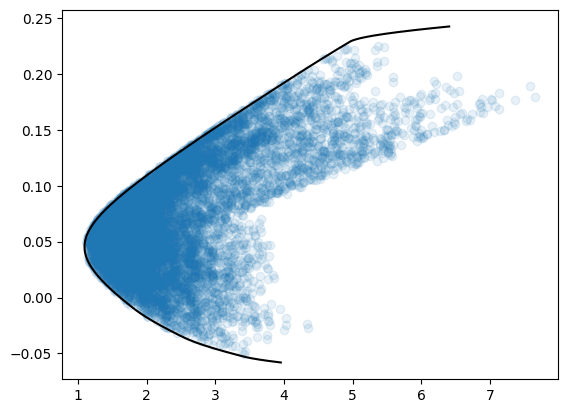

In [45]:
plt.scatter(risks, returns, alpha=0.1);
plt.plot(optimized_risks, target_returns, c='black');

In [46]:
# Min variance portfolio
# Let's limit the magnitude of the weights
res = minimize(
    fun=get_portfolio_variance,
    x0=np.ones(D) / D, # uniform
    method='SLSQP',
    constraints={
        'type': 'eq',
        'fun': portfolio_constraint,
    },
    bounds=bounds,
)
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 1.2030612148576356
       x: [ 3.003e-02  8.963e-02  4.931e-02  1.827e-01  6.483e-01]
     nit: 5
     jac: [ 2.406e+00  2.406e+00  2.406e+00  2.406e+00  2.406e+00]
    nfev: 34
    njev: 5

In [47]:
#Now to find minimium risk
my_risk = np.sqrt(res.fun)
my_weights = res.x
my_ret = my_weights.dot(mean_return)

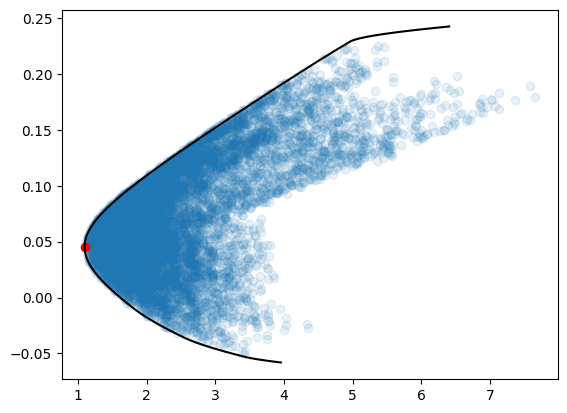

In [48]:
plt.scatter(risks , returns, alpha=0.1);
plt.plot(optimized_risks, target_returns, c='black');
plt.scatter([my_risk], [my_ret], c='red');